In [ ]:
import pandas as pd
import glob

import matplotlib.pyplot as plt


from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def preprocess_tempseries(temp):

    # fills gaps up to 2 hour
    # 5-min x 24 samples = 120 minutes (2 hours)
    s_filled = temp.interpolate(method="time", limit=24)

    # temp is 5-min temperature Series with DatetimeIndex
    daily_mean = s_filled.resample("1D").mean()

    # Smooth daily means with a 15-day centered rolling mean
    daily_smooth = (
        daily_mean
        .rolling(15, center=True, min_periods=5)
        .mean()
    )

    # Interpolate smooth daily background back to 5-min timestamps
    slow_component = (
        daily_smooth
        .reindex(s_filled.index)
        .interpolate(method="time")
    )

    detrended = s_filled - slow_component

    diurnal_cycle = detrended.groupby(
        detrended.index.time).transform("mean")

    anom = detrended - diurnal_cycle

    df_temp = pd.DataFrame({
        "temp_original": temp,
        "temp_filled": s_filled,
        "slow_component": slow_component,
        "diurnal_cycle": diurnal_cycle,
        "anom": anom,
    })

    return df_temp

In [ ]:
goodstations = []
badstations = []

for file_name in files:

    df = pd.read_csv(file_name)
    df['obsTimeLocal'] = pd.to_datetime(df['obsTimeLocal'])

    start = '2023-05-23 00:00:00'
    end = '2023-10-07 23:55:00'
    df_subset = df.loc[
        (df['obsTimeLocal'] >= start) &
        (df['obsTimeLocal'] <= end)
    ]

    # what are missing data sequence lengths?
    tmp_count = df_subset[df_subset['tempAvg'].isna()].groupby(
        df_subset['tempAvg'].notna().cumsum()[
            df_subset['tempAvg'].isna()])['obsTimeLocal'].agg(
                ['first', 'last', 'size']).sort_values(
                    'size', ascending=False).iloc[0]

    # if missing more than 2 hours (consecutive)
    if tmp_count.iloc[2]>=24:
        print(tmp_count, file_name)
        badstations.append(file_name)

    # if record doesn't start on startdate
    elif pd.to_datetime(
        df_subset['obsTimeLocal'].iloc[0]) != pd.Timestamp(
            '2023-05-23 00:00:00'):
        print(tmp_count, file_name)
        badstations.append(file_name)

    else:
        goodstations.append(file_name)

first    2023-08-25 02:05:00
last     2023-08-25 02:30:00
size                       6
Name: 4499, dtype: object /content/drive/MyDrive/GNN_Baltimore/station_dataset/raw/data/5min/2023/BSEC-ABL_AWS_5min_2023.csv
first    2023-09-23 17:40:00
last     2023-10-05 11:15:00
size                    3380
Name: 1843, dtype: object /content/drive/MyDrive/GNN_Baltimore/station_dataset/raw/data/5min/2023/BSEC-AGC_AWS_5min_2023.csv
first    2023-08-09 07:55:00
last     2023-08-09 08:25:00
size                       7
Name: 6174, dtype: object /content/drive/MyDrive/GNN_Baltimore/station_dataset/raw/data/5min/2023/BSEC-ARK_AWS_5min_2023.csv
first    2023-10-03 13:50:00
last     2023-10-03 13:50:00
size                       1
Name: 0, dtype: object /content/drive/MyDrive/GNN_Baltimore/station_dataset/raw/data/5min/2023/BSEC-CARE_OTT_5min_2023.csv
first    2023-09-18 13:05:00
last     2023-09-18 13:15:00
size                       3
Name: 10751, dtype: object /content/drive/MyDrive/GNN_Baltimore/sta

In [ ]:
goodstations

['/content/drive/MyDrive/GNN_Baltimore/station_dataset/raw/data/5min/2023/BSEC-AAC_AWS_5min_2023.csv',
 '/content/drive/MyDrive/GNN_Baltimore/station_dataset/raw/data/5min/2023/BSEC-COV_AWS_5min_2023.csv',
 '/content/drive/MyDrive/GNN_Baltimore/station_dataset/raw/data/5min/2023/BSEC-JHU_AWS_5min_2023.csv']

In [ ]:
station_dfs = {}

for file_name in goodstations:

    df = pd.read_csv(file_name)
    df['obsTimeLocal'] = pd.to_datetime(df['obsTimeLocal'])

    start = '2023-05-23 00:00:00'
    end = '2023-10-07 23:55:00'
    df_subset = df.loc[
        (df['obsTimeLocal'] >= start) &
        (df['obsTimeLocal'] <= end)
    ]

    temp = (
        df_subset
        .set_index('obsTimeLocal')
        .sort_index()
    )['tempAvg'].asfreq('5min')

    station_dfs[Path(file_name).name] = preprocess_tempseries(temp)

In [ ]:
station_dfs['BSEC-AAC_AWS_5min_2023.csv']

,temp_original,temp_filled,slow_component,diurnal_cycle,anom
obsTimeLocal,,,,,
2023-05-23 00:00:00,18.8,18.8,19.284462,-1.956660,1.472198
2023-05-23 00:05:00,18.8,18.8,19.284571,-1.991112,1.506541
2023-05-23 00:10:00,18.8,18.8,19.284680,-2.035709,1.551029
2023-05-23 00:15:00,18.7,18.7,19.284789,-2.086104,1.501314
2023-05-23 00:20:00,18.7,18.7,19.284898,-2.142295,1.557397
...,...,...,...,...,...
2023-10-07 23:35:00,11.6,11.6,20.553754,-1.770408,-7.183346
2023-10-07 23:40:00,11.3,11.3,20.553754,-1.828773,-7.424981
2023-10-07 23:45:00,11.4,11.4,20.553754,-1.873008,-7.280746


In [ ]:
goodstations = [Path(f).name for f in goodstations]

In [ ]:
plt.rcParams['font.size'] = 12

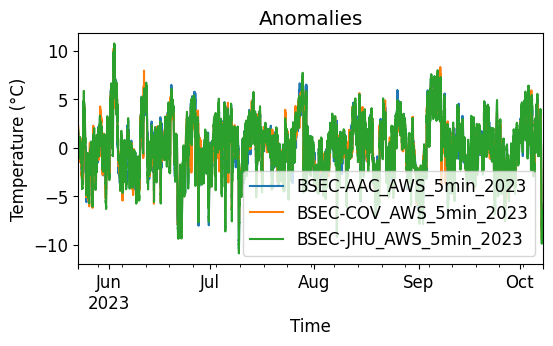

In [ ]:
plt.figure(figsize=(6, 3))

station_dfs[goodstations[0]]["anom"].plot();
station_dfs[goodstations[1]]["anom"].plot();
station_dfs[goodstations[2]]["anom"].plot()

plt.legend([f[:-4] for f in goodstations])
plt.ylabel("Temperature (°C)")
plt.xlabel("Time")
plt.title("Anomalies")
plt.savefig("anom.pdf")

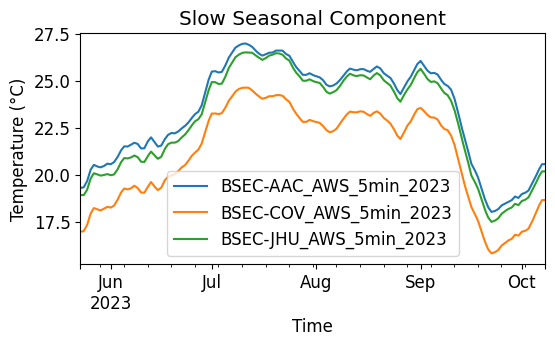

In [ ]:
plt.figure(figsize=(6, 3))

station_dfs[goodstations[0]]["slow_component"].plot();
station_dfs[goodstations[1]]["slow_component"].plot();
station_dfs[goodstations[2]]["slow_component"].plot()

plt.legend([f[:-4] for f in goodstations])
plt.ylabel("Temperature (°C)")
plt.xlabel("Time")
plt.title("Slow Seasonal Component")
plt.savefig("seasonal.pdf")

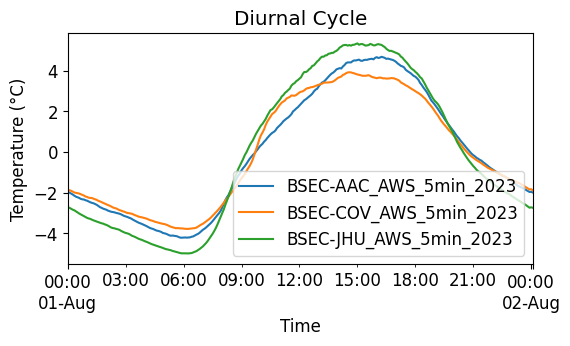

In [ ]:
plt.figure(figsize=(6, 3))

station_dfs[goodstations[0]]["diurnal_cycle"].iloc[20160:20450].plot();
station_dfs[goodstations[1]]["diurnal_cycle"].iloc[20160:20450].plot();
station_dfs[goodstations[2]]["diurnal_cycle"].iloc[20160:20450].plot()

plt.legend([f[:-4] for f in goodstations])
plt.ylabel("Temperature (°C)")
plt.xlabel("Time")
plt.title("Diurnal Cycle")
plt.savefig("diurnal.pdf")

In [ ]:
station_dfs[goodstations[0]].to_csv('/content/drive/MyDrive/processed_'+list(station_dfs.keys())[0]);
station_dfs[goodstations[1]].to_csv('/content/drive/MyDrive/processed_'+list(station_dfs.keys())[1]);
station_dfs[goodstations[2]].to_csv('/content/drive/MyDrive/processed_'+list(station_dfs.keys())[2])